In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_camp_table = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_table.csv")
df_camp_desc = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_desc.csv")
df_coupon_red = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon_redempt.csv")
df_coupon = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon.csv")
df_trxn = pd.read_csv("../dunnhumby_The-Complete-Journey/transaction_data.csv")
df_product = pd.read_csv("../dunnhumby_The-Complete-Journey/product.csv")
df_segmented = pd.read_csv("../dunnhumby_The-Complete-Journey/segmented_df.csv")

In [3]:
df_camp_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [4]:
count_camps_per_hsld = df_camp_table.groupby('household_key')['CAMPAIGN'].count().reset_index()
count_camps_per_hsld.rename(columns={'CAMPAIGN': 'count_per_hsld'}, inplace=True)
count_camps_per_hsld.head(10)

,household_key,count_per_hsld
0,1,8
1,2,1
2,3,3
3,4,1
4,6,4
5,7,4
6,8,10
7,13,10
8,14,5
9,16,2


In [5]:
count_camps_per_hsld.shape

(1584, 2)

In [6]:
tab2 =df_trxn.groupby('household_key')['BASKET_ID'].nunique().reset_index()

In [7]:
tab2.head()

,household_key,BASKET_ID
0,1,86
1,2,45
2,3,47
3,4,30
4,5,40


In [8]:
hh_camp_mapping = pd.merge(left = tab2, right=count_camps_per_hsld, how='left', on='household_key').fillna(0).drop(columns=['BASKET_ID'])
hh_camp_mapping.head(10)

,household_key,count_per_hsld
0,1,8.0
1,2,1.0
2,3,3.0
3,4,1.0
4,5,0.0
5,6,4.0
6,7,4.0
7,8,10.0
8,9,0.0
9,10,0.0


In [9]:
hh_camp_mapping.shape

(2500, 2)

In [10]:
df_coupon_red.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [11]:
df_coupon_red.duplicated().sum()

np.int64(0)

In [12]:
coupon_red_1 = df_coupon_red.loc[:,['household_key','CAMPAIGN']]

In [13]:
coupon_red_2 = coupon_red_1.drop_duplicates().groupby('household_key')['CAMPAIGN'].count().reset_index()
coupon_red_2.rename(columns={'CAMPAIGN': 'distinct_count_per_hsld'}, inplace=True)

In [14]:
coupon_red_2.head()

,household_key,distinct_count_per_hsld
0,1,2
1,8,1
2,13,7
3,14,1
4,18,3


In [15]:
hh_camp_mapping.head()

,household_key,count_per_hsld
0,1,8.0
1,2,1.0
2,3,3.0
3,4,1.0
4,5,0.0


In [16]:
no_of_camps_per_hsld =hh_camp_mapping.groupby('count_per_hsld').count().reset_index()

In [17]:
no_of_camps_per_hsld.head()

,count_per_hsld,household_key
0,0.0,916
1,1.0,268
2,2.0,224
3,3.0,214
4,4.0,169


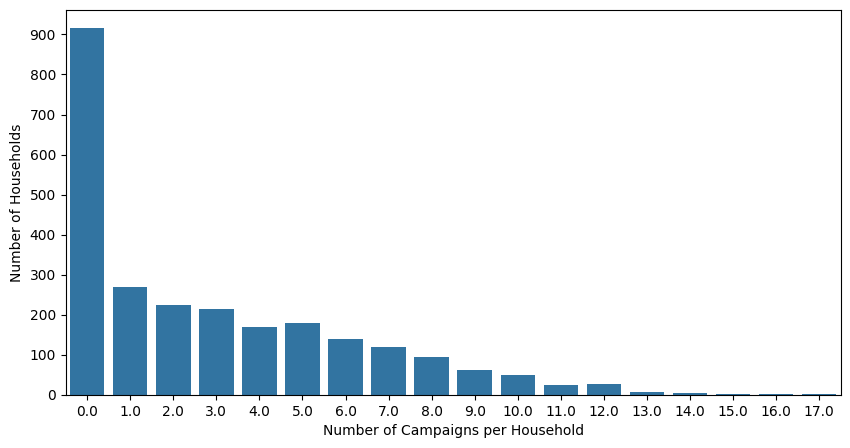

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x=no_of_camps_per_hsld['count_per_hsld'], y=no_of_camps_per_hsld['household_key'], data=no_of_camps_per_hsld)
plt.xlabel('Number of Campaigns per Household')
plt.ylabel('Number of Households')
plt.yticks(np.arange(0, 1000, 100))
plt.show()

In [19]:
coupon_red_2.head()

,household_key,distinct_count_per_hsld
0,1,2
1,8,1
2,13,7
3,14,1
4,18,3


In [20]:
camp_rdmptn_rate=pd.merge(hh_camp_mapping,coupon_red_2,on='household_key',how='outer').fillna(0)

In [21]:
camp_rdmptn_rate.head()

,household_key,count_per_hsld,distinct_count_per_hsld
0,1,8.0,2.0
1,2,1.0,0.0
2,3,3.0,0.0
3,4,1.0,0.0
4,5,0.0,0.0


In [22]:
camp_rdmptn_rate['camp_rdmptn_rate']=camp_rdmptn_rate['distinct_count_per_hsld']/camp_rdmptn_rate['count_per_hsld']
camp_rdmptn_rate.sort_values(['distinct_count_per_hsld','count_per_hsld'],ascending=False).head(30)

,household_key,count_per_hsld,distinct_count_per_hsld,camp_rdmptn_rate
255,256,12.0,10.0,0.833333
366,367,9.0,9.0,1.000000
978,979,13.0,8.0,0.615385
888,889,12.0,8.0,0.666667
981,982,14.0,7.0,0.500000
2279,2280,13.0,7.0,0.538462
12,13,10.0,7.0,0.700000
463,464,10.0,7.0,0.700000
2450,2451,9.0,7.0,0.777778
21,22,8.0,7.0,0.875000


building the household x week panel

In [23]:
# merge campaign table with desc to get start/end days
camp_full = df_camp_table.merge(df_camp_desc, on=['CAMPAIGN', 'DESCRIPTION'])

# tag transactions with their campaigns (only enrolled households)
txn_camp = df_trxn.merge(
    camp_full[['household_key', 'CAMPAIGN', 'DESCRIPTION', 'START_DAY', 'END_DAY']],
    on='household_key',
    how='inner'
)

# aggregate to hh x campaign x week
panel = txn_camp.groupby(
    ['household_key', 'CAMPAIGN', 'DESCRIPTION', 'START_DAY', 'END_DAY', 'WEEK_NO']
).agg(
    sales=('SALES_VALUE', 'sum'),
    quantity=('QUANTITY', 'sum')
).reset_index()

print(panel.shape)
panel.head(10)

(518359, 8)


,household_key,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO,sales,quantity
0,1,8,TypeA,412,460,8,78.66,34
1,1,8,TypeA,412,460,10,41.10,14
2,1,8,TypeA,412,460,13,26.90,13
3,1,8,TypeA,412,460,14,63.43,32
4,1,8,TypeA,412,460,15,53.45,20
5,1,8,TypeA,412,460,16,26.76,11
6,1,8,TypeA,412,460,17,23.55,12
7,1,8,TypeA,412,460,19,110.34,43
8,1,8,TypeA,412,460,20,87.44,43
9,1,8,TypeA,412,460,22,73.32,32


adding campaign dummy variable

In [24]:
# convert days to weeks
panel['camp_start_week'] = (panel['START_DAY'] / 7).apply(np.ceil).astype(int)
panel['camp_end_week'] = (panel['END_DAY'] / 7).apply(np.ceil).astype(int)

# flag if the week is inside the campaign window
panel['in_campaign'] = (
    (panel['WEEK_NO'] >= panel['camp_start_week']) &
    (panel['WEEK_NO'] <= panel['camp_end_week'])
).astype(int)

# period label
def label_period(row):
    if row['WEEK_NO'] < row['camp_start_week']:
        return 'pre'
    elif row['WEEK_NO'] <= row['camp_end_week']:
        return 'during'
    else:
        return 'post'

panel['period'] = panel.apply(label_period, axis=1)

print(panel['in_campaign'].value_counts())
print(panel['period'].value_counts())

in_campaign
0    477449
1     40910
Name: count, dtype: int64
period
pre       343780
post      133669
during     40910
Name: count, dtype: int64


finding the lag

trying to see how many weeks after campaign start the spending actually peaks. helps decide the lag to use in the regression.

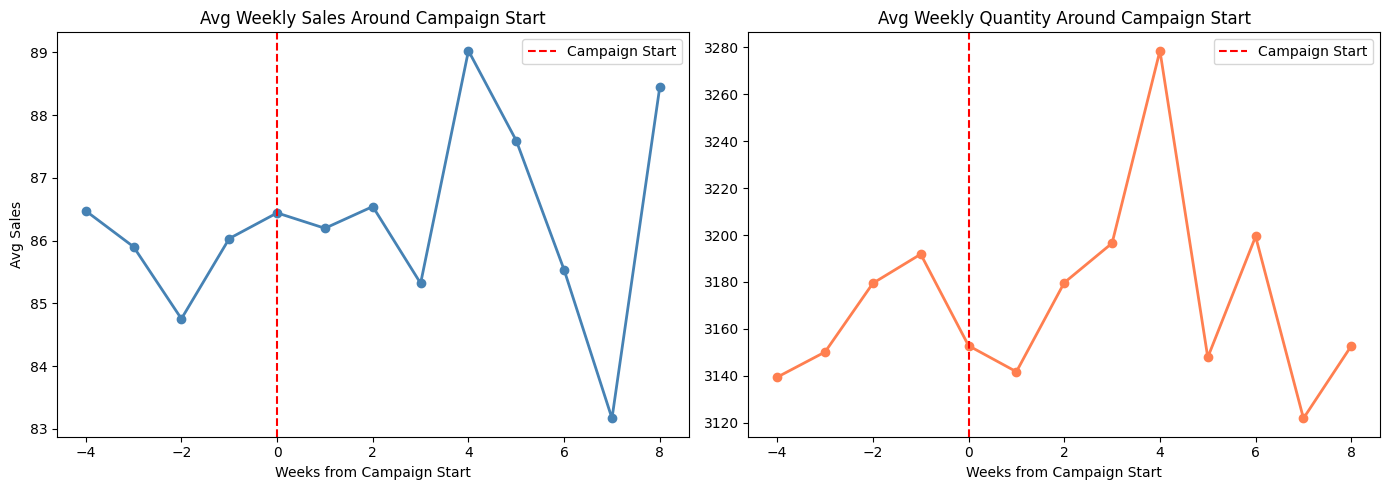

    weeks_from_start  avg_sales      avg_qty
0                 -4  86.474024  3139.429710
1                 -3  85.901683  3150.151650
2                 -2  84.754408  3179.449867
3                 -1  86.032944  3191.841364
4                  0  86.441398  3152.827988
5                  1  86.196506  3141.735210
6                  2  86.542793  3179.682892
7                  3  85.319396  3196.528108
8                  4  89.025075  3278.543838
9                  5  87.591940  3147.857143
10                 6  85.532987  3199.377577
11                 7  83.168686  3121.878976
12                 8  88.451949  3152.754416


In [25]:
import matplotlib.pyplot as plt

# weeks relative to campaign start
panel['weeks_from_start'] = panel['WEEK_NO'] - panel['camp_start_week']

# look at -4 to +8 weeks around start
window = panel[panel['weeks_from_start'].between(-4, 8)]

lag_profile = window.groupby('weeks_from_start').agg(
    avg_sales=('sales', 'mean'),
    avg_qty=('quantity', 'mean')
).reset_index()

# plot sales and qty side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lag_profile['weeks_from_start'], lag_profile['avg_sales'], marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=0, color='red', linestyle='--', label='Campaign Start')
axes[0].set_title('Avg Weekly Sales Around Campaign Start')
axes[0].set_xlabel('Weeks from Campaign Start')
axes[0].set_ylabel('Avg Sales')
axes[0].legend()

axes[1].plot(lag_profile['weeks_from_start'], lag_profile['avg_qty'], marker='o', color='coral', linewidth=2)
axes[1].axvline(x=0, color='red', linestyle='--', label='Campaign Start')
axes[1].set_title('Avg Weekly Quantity Around Campaign Start')
axes[1].set_xlabel('Weeks from Campaign Start')
axes[1].legend()

plt.tight_layout()
plt.show()

print(lag_profile)